In [ ]:
!pip install diffprivlib aif360


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.5/176.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 11.4 MB/s eta 0:00:00


In [ ]:
from google.colab import files
uploaded = files.upload()


TypeError: 'NoneType' object is not subscriptable

In [ ]:
import pandas as pd

# Load the data
df = pd.read_csv("diabetic_data.csv")


In [ ]:
# Drop unnecessary columns
df.drop(columns=["encounter_id", "patient_nbr", "weight", "payer_code", "medical_specialty"], inplace=True)

# Remove missing or unknown values
df = df[(df['race'] != '?') & (df['gender'] != 'Unknown/Invalid')]

# Convert target: 1 = <30 days, 0 = No or >30
df['readmitted'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

# Encode all categorical columns
from sklearn.preprocessing import LabelEncoder

label_cols = df.select_dtypes(include='object').columns
encoders = {}
for col in label_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le


<ipython-input-9-47443f3622d6>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['readmitted'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)


In [ ]:
# Balance the classes
readmitted_1 = df[df['readmitted'] == 1]
readmitted_0 = df[df['readmitted'] == 0].sample(n=len(readmitted_1), random_state=42)

df_balanced = pd.concat([readmitted_1, readmitted_0]).sample(frac=1, random_state=42)

# Define features and labels
X = df_balanced.drop(columns=["readmitted"])
y = df_balanced["readmitted"]


In [ ]:
from sklearn.model_selection import train_test_split
from diffprivlib.models import RandomForestClassifier as DP_RF
from sklearn.metrics import classification_report

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Train the model with privacy
model = DP_RF(n_estimators=50, epsilon=1.0)
model.fit(X_train, y_train)

# Predictions and report
y_pred = model.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/diffprivlib/models/forest.py:190: PrivacyLeakWarning: Bounds have not been specified and will be calculated on the data provided. This will result in additional privacy leakage. To ensure differential privacy and no additional privacy leakage, specify bounds for each dimension.
  warnings.warn("Bounds have not been specified and will be calculated on the data provided. This will "
/usr/local/lib/python3.11/dist-packages/diffprivlib/models/forest.py:209: PrivacyLeakWarning: Classes have not been specified and will be calculated on the data provided. This will result in additional privacy leakage. To ensure differential privacy and no additional priva

Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.65      0.58      2234
           1       0.55      0.42      0.47      2234

    accuracy                           0.54      4468
   macro avg       0.54      0.54      0.53      4468
weighted avg       0.54      0.54      0.53      4468



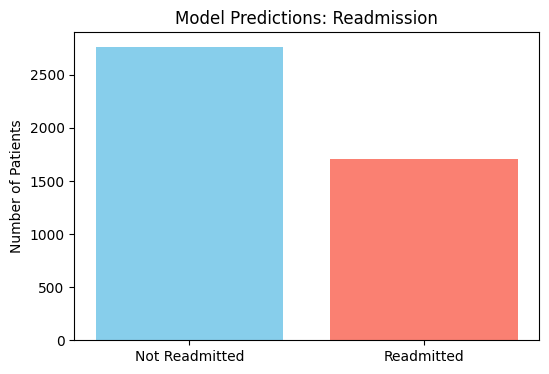

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

pred_counts = np.bincount(y_pred)
labels = ['Not Readmitted', 'Readmitted']
colors = ['skyblue', 'salmon']

plt.figure(figsize=(6,4))
plt.bar(labels, pred_counts, color=colors)
plt.title("Model Predictions: Readmission")
plt.ylabel("Number of Patients")
plt.show()


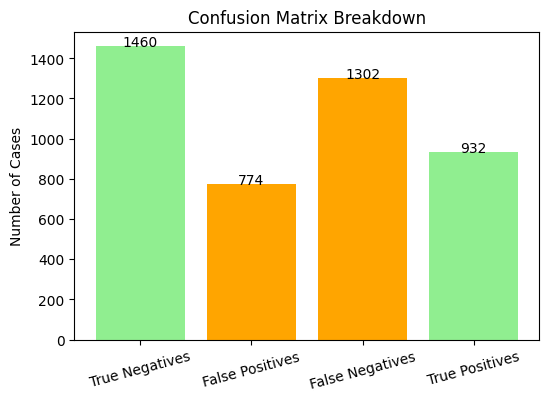

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

labels = ['True Negatives', 'False Positives', 'False Negatives', 'True Positives']
values = [tn, fp, fn, tp]
colors = ['lightgreen', 'orange', 'orange', 'lightgreen']

plt.figure(figsize=(6,4))
plt.bar(labels, values, color=colors)
plt.title("Confusion Matrix Breakdown")
for i, val in enumerate(values):
    plt.text(i, val + 1, str(val), ha='center')
plt.ylabel("Number of Cases")
plt.xticks(rotation=15)
plt.show()


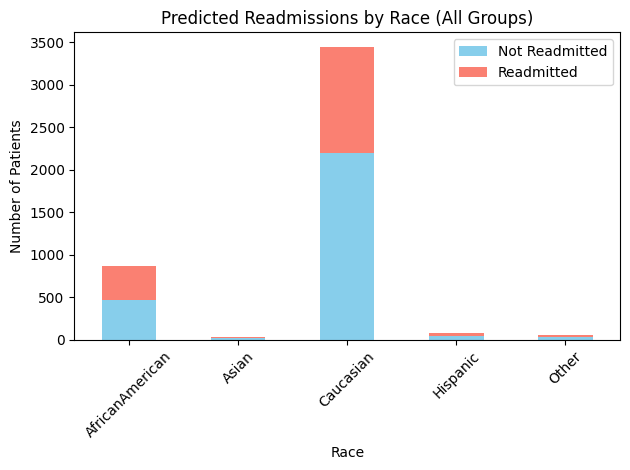

In [ ]:
# Decode race back to labels for visualization
race_labels = df.loc[X_test.index, 'race']
decoded_race = encoders["race"].inverse_transform(race_labels)

# Combine with predictions
viz_df = pd.DataFrame({
    "race": decoded_race,
    "prediction": y_pred
})

# Group by race and prediction
race_pred_counts_all = viz_df.groupby(["race", "prediction"]).size().unstack(fill_value=0)

# Plot
race_pred_counts_all.plot(kind="bar", stacked=True, color=['skyblue', 'salmon'])
plt.title("Predicted Readmissions by Race (All Groups)")
plt.ylabel("Number of Patients")
plt.xlabel("Race")
plt.legend(["Not Readmitted", "Readmitted"])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
